In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [3]:
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x) # setting display to show float numbers upto 2 decimal points

In [8]:
original_df = pd.read_csv(r"C:\Users\HP\Air_Pollution_Analysis\GlobalWeatherRepository_2.csv")

In [10]:
df = original_df[['country', 'location_name', 'latitude', 'longitude', 'last_updated',
       'temperature_celsius', 'condition_text', 'wind_kph', 'wind_direction',
       'pressure_mb', 'precip_mm', 'humidity', 'feels_like_celsius',
       'visibility_km', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'date',
       'time']].copy()

In [18]:
df_small = df.sample(5000)
df_small.to_csv(r"C:\Users\HP\Air_Pollution_Analysis\sample_data.csv", index=False)

In [20]:
df.shape

(134098, 25)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134098 entries, 0 to 134097
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       134098 non-null  object 
 1   location_name                 134098 non-null  object 
 2   latitude                      134098 non-null  float64
 3   longitude                     134098 non-null  float64
 4   last_updated                  134098 non-null  object 
 5   temperature_celsius           134098 non-null  float64
 6   condition_text                134098 non-null  object 
 7   wind_kph                      134098 non-null  float64
 8   wind_direction                134098 non-null  object 
 9   pressure_mb                   134098 non-null  float64
 10  precip_mm                     134098 non-null  float64
 11  humidity                      134098 non-null  int64  
 12  feels_like_celsius            134098 non-nul

In [24]:
df.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
last_updated                    0
temperature_celsius             0
condition_text                  0
wind_kph                        0
wind_direction                  0
pressure_mb                     0
precip_mm                       0
humidity                        0
feels_like_celsius              0
visibility_km                   0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Nitrogen_dioxide    0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
air_quality_us-epa-index        0
air_quality_gb-defra-index      0
date                            0
time                            0
dtype: int64

## EDA

In [27]:
# Identify duplicate rows
#duplicateRows = df[df.duplicated()]
# View duplicate rows
#print(duplicateRows)
df.drop_duplicates(inplace =True)

In [29]:
# converting data and time to their format
df['date'] = pd.to_datetime(df['date'])
df['time'] = pd.to_datetime(df['time']).dt.time


C:\Users\HP\AppData\Local\Temp\ipykernel_7608\2513428495.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['time']).dt.time


In [31]:
df.describe()

,latitude,longitude,temperature_celsius,wind_kph,pressure_mb,precip_mm,humidity,feels_like_celsius,visibility_km,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,date
count,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097.00,134097
mean,19.21,21.96,21.30,12.92,1014.06,0.14,66.60,22.16,9.50,18.27,462.83,58.17,15.03,10.40,24.25,48.48,1.70,2.61,2025-04-26 08:43:35.253137664
min,-41.30,-175.20,-29.80,3.60,947.00,0.00,2.00,-36.70,0.00,3.60,-9999.00,0.00,0.00,-9999.00,0.17,-1848.15,1.00,1.00,2024-05-16 00:00:00
25%,4.05,-6.84,16.00,6.10,1010.00,0.00,51.00,16.00,10.00,10.30,203.60,38.00,1.67,1.11,7.05,9.99,1.00,1.00,2024-11-05 00:00:00
50%,17.25,23.24,24.00,10.80,1014.00,0.00,72.00,25.20,10.00,15.30,296.00,55.00,5.55,2.40,14.24,19.98,1.00,2.00,2025-04-27 00:00:00
75%,40.40,49.88,28.00,17.60,1018.00,0.03,86.00,30.00,10.00,24.20,462.50,74.00,17.39,8.32,27.80,41.62,2.00,3.00,2025-10-16 00:00:00
max,64.15,179.22,49.20,2963.20,3006.00,42.24,100.00,51.20,32.00,2970.40,38879.40,480.70,427.70,521.33,1614.10,6037.29,6.00,10.00,2026-04-07 00:00:00
std,24.42,65.79,9.70,11.65,10.39,0.57,23.91,11.60,2.69,13.85,760.78,30.81,23.77,35.81,37.00,149.61,0.94,2.45,NaN


In [33]:
# List of columns that physically cannot be negative
positive_only = ['wind_kph', 'precip_mm', 'humidity', 'visibility_km', 'gust_kph', 
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 
    'air_quality_PM2.5', 'air_quality_PM10']

# Replace any value below 0 with NaN (Not a Number)
for col in positive_only:
    df.loc[df[col] < 0, col] = np.nan

In [35]:
# Cap Wind/Gust at a realistic extreme (e.g., 200 kph)
df.loc[df['wind_kph'] > 200, 'wind_kph'] = np.nan
df.loc[df['gust_kph'] > 200, 'gust_kph'] = np.nan

# Fix Pressure (Realistic range is usually 950 - 1050 mb)
df.loc[(df['pressure_mb'] < 800) | (df['pressure_mb'] > 1100), 'pressure_mb'] = np.nan

# Air Quality PM2.5 / PM10 
df.loc[df['air_quality_PM2.5'] > 500, 'air_quality_PM2.5'] = np.nan
df.loc[df['air_quality_PM10'] > 500, 'air_quality_PM10'] = np.nan

In [37]:
df.isnull().sum()

country                            0
location_name                      0
latitude                           0
longitude                          0
last_updated                       0
temperature_celsius                0
condition_text                     0
wind_kph                           4
wind_direction                     0
pressure_mb                        2
precip_mm                          0
humidity                           0
feels_like_celsius                 0
visibility_km                      0
gust_kph                           4
air_quality_Carbon_Monoxide        1
air_quality_Ozone                  0
air_quality_Nitrogen_dioxide       0
air_quality_Sulphur_dioxide        1
air_quality_PM2.5                 86
air_quality_PM10                1279
air_quality_us-epa-index           0
air_quality_gb-defra-index         0
date                               0
time                               0
dtype: int64

In [39]:
df.dropna(inplace=True)

In [41]:
df.describe()

,latitude,longitude,temperature_celsius,wind_kph,pressure_mb,precip_mm,humidity,feels_like_celsius,visibility_km,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,date
count,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810.00,132810
mean,19.22,21.92,21.24,12.82,1014.05,0.14,66.98,22.10,9.51,18.16,454.87,58.04,14.86,10.25,22.51,38.01,1.67,2.54,2025-04-26 15:16:21.522475520
min,-41.30,-175.20,-29.80,3.60,947.00,0.00,2.00,-36.70,0.00,3.60,53.85,0.00,0.00,0.00,0.17,0.17,1.00,1.00,2024-05-16 00:00:00
25%,3.75,-6.84,16.00,6.10,1010.00,0.00,51.00,16.00,10.00,10.20,203.60,38.00,1.67,1.11,7.03,9.90,1.00,1.00,2024-11-05 00:00:00
50%,17.25,21.43,24.00,10.80,1014.00,0.00,72.00,25.10,10.00,15.30,294.15,55.00,5.55,2.40,14.06,19.80,1.00,2.00,2025-04-27 00:00:00
75%,41.32,50.58,28.00,17.60,1018.00,0.03,86.00,29.90,10.00,24.10,460.65,74.00,17.20,8.14,27.20,40.52,2.00,3.00,2025-10-17 00:00:00
max,64.15,179.22,49.20,172.10,1080.00,42.24,100.00,51.20,32.00,179.30,18585.20,480.70,427.70,521.33,446.22,499.69,6.00,10.00,2026-04-07 00:00:00
std,24.49,66.00,9.67,8.30,7.00,0.57,23.61,11.60,2.70,11.14,663.82,30.76,23.53,22.76,27.78,55.70,0.90,2.35,NaN


##  Visualization

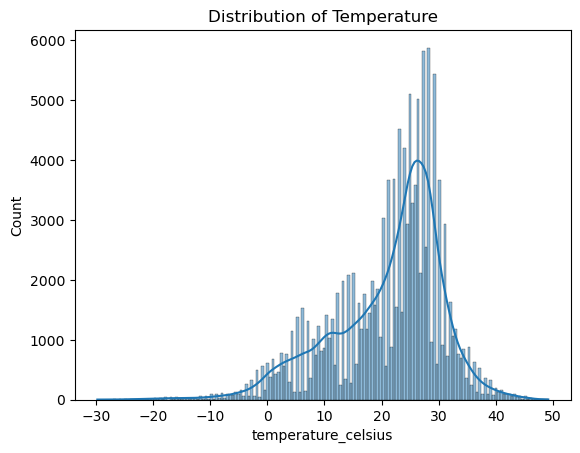

In [44]:
#Distribution of Temperature

sns.histplot(df['temperature_celsius'], kde=True)
plt.title("Distribution of Temperature")
plt.show()

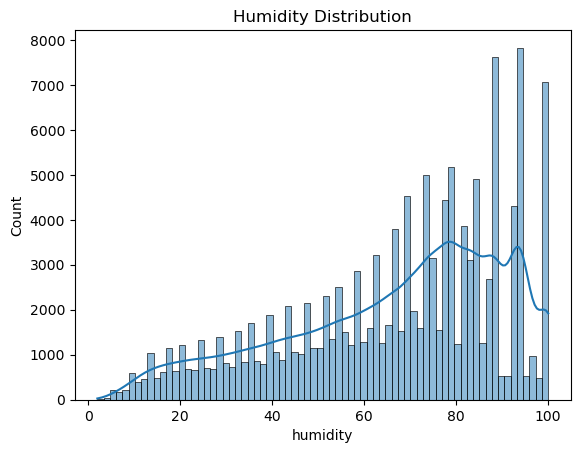

In [46]:
# Humidity Distribution

sns.histplot(df['humidity'], kde=True)
plt.title("Humidity Distribution")
plt.show()

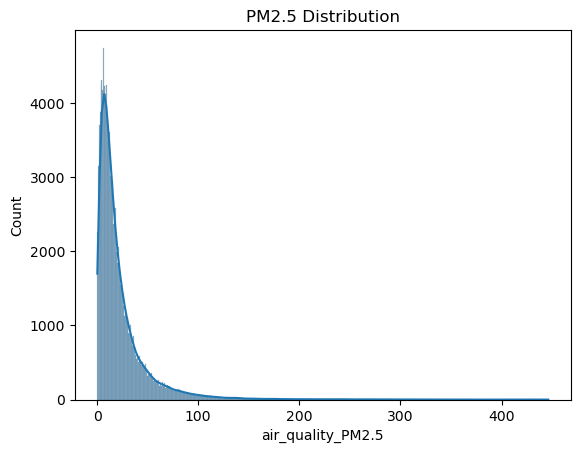

In [48]:
# PM2.5 Distribution

sns.histplot(df['air_quality_PM2.5'], kde=True)
plt.title("PM2.5 Distribution")
#plt.savefig(r"C:\Users\HP\Air_Pollution_Analysis\Images\pm25_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

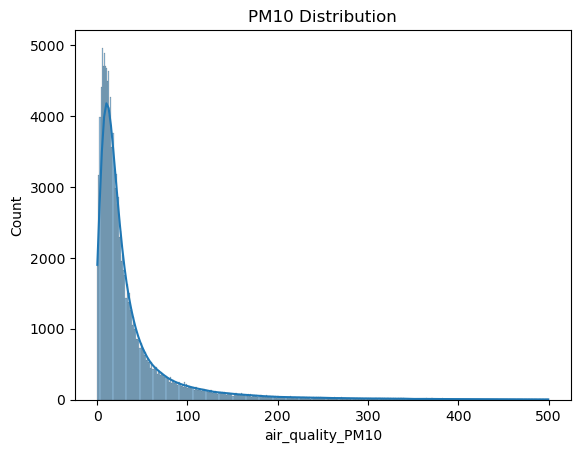

In [50]:
# PM10 Distribution

sns.histplot(df['air_quality_PM10'], kde=True)
plt.title("PM10 Distribution")
plt.show()

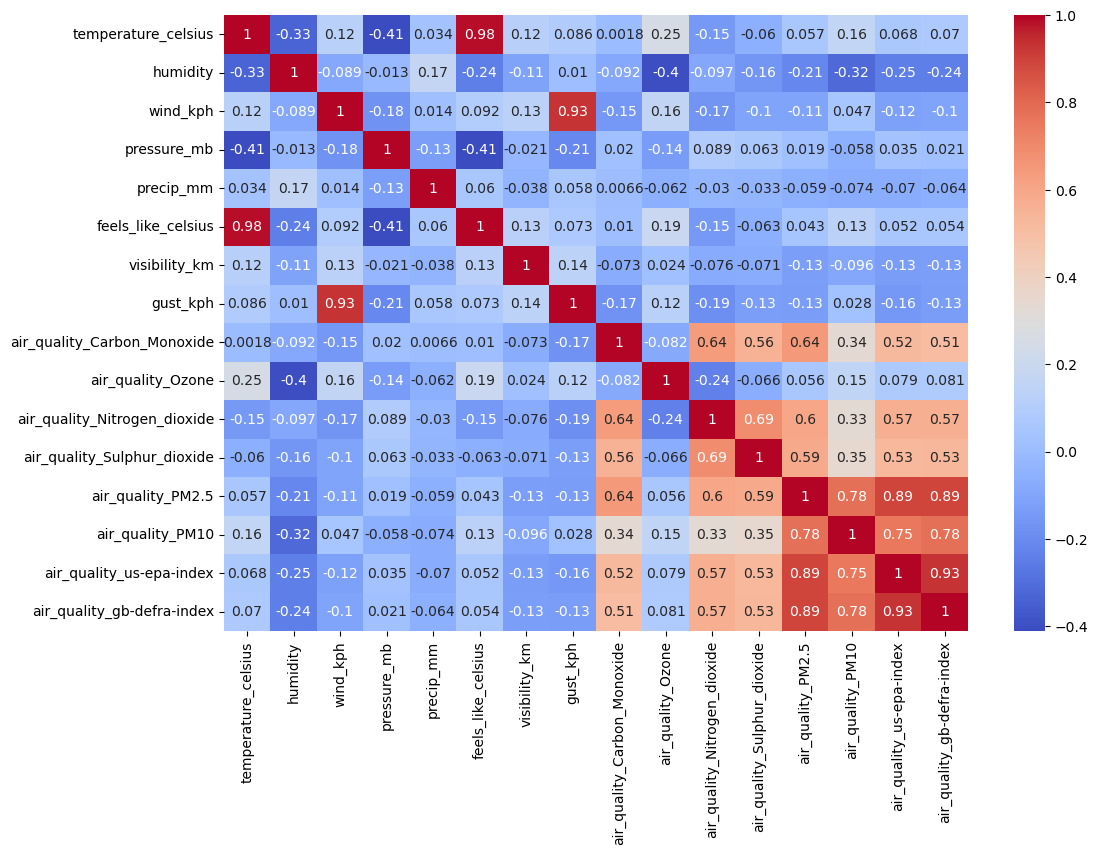

In [52]:
# Identifying strong correlations between features

corr = df[['temperature_celsius', 'humidity','wind_kph', 'pressure_mb', 'precip_mm',  'feels_like_celsius', 
           'visibility_km', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 
           'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
           'air_quality_us-epa-index', 'air_quality_gb-defra-index']].corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
#plt.savefig(r"C:\Users\HP\Air_Pollution_Analysis\Images\correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [54]:
# Group the data by year and month, and compute the average for selected numerical features
# This helps analyze seasonal and monthly trends across weather and air quality variables

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

year_month_avgs = df.groupby(['year','month'])[['temperature_celsius','humidity','feels_like_celsius', 'wind_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index','visibility_km']].mean(numeric_only=True)
                                                                                      
styled_df = year_month_avgs.style.background_gradient(cmap='coolwarm', axis=0)
styled_df

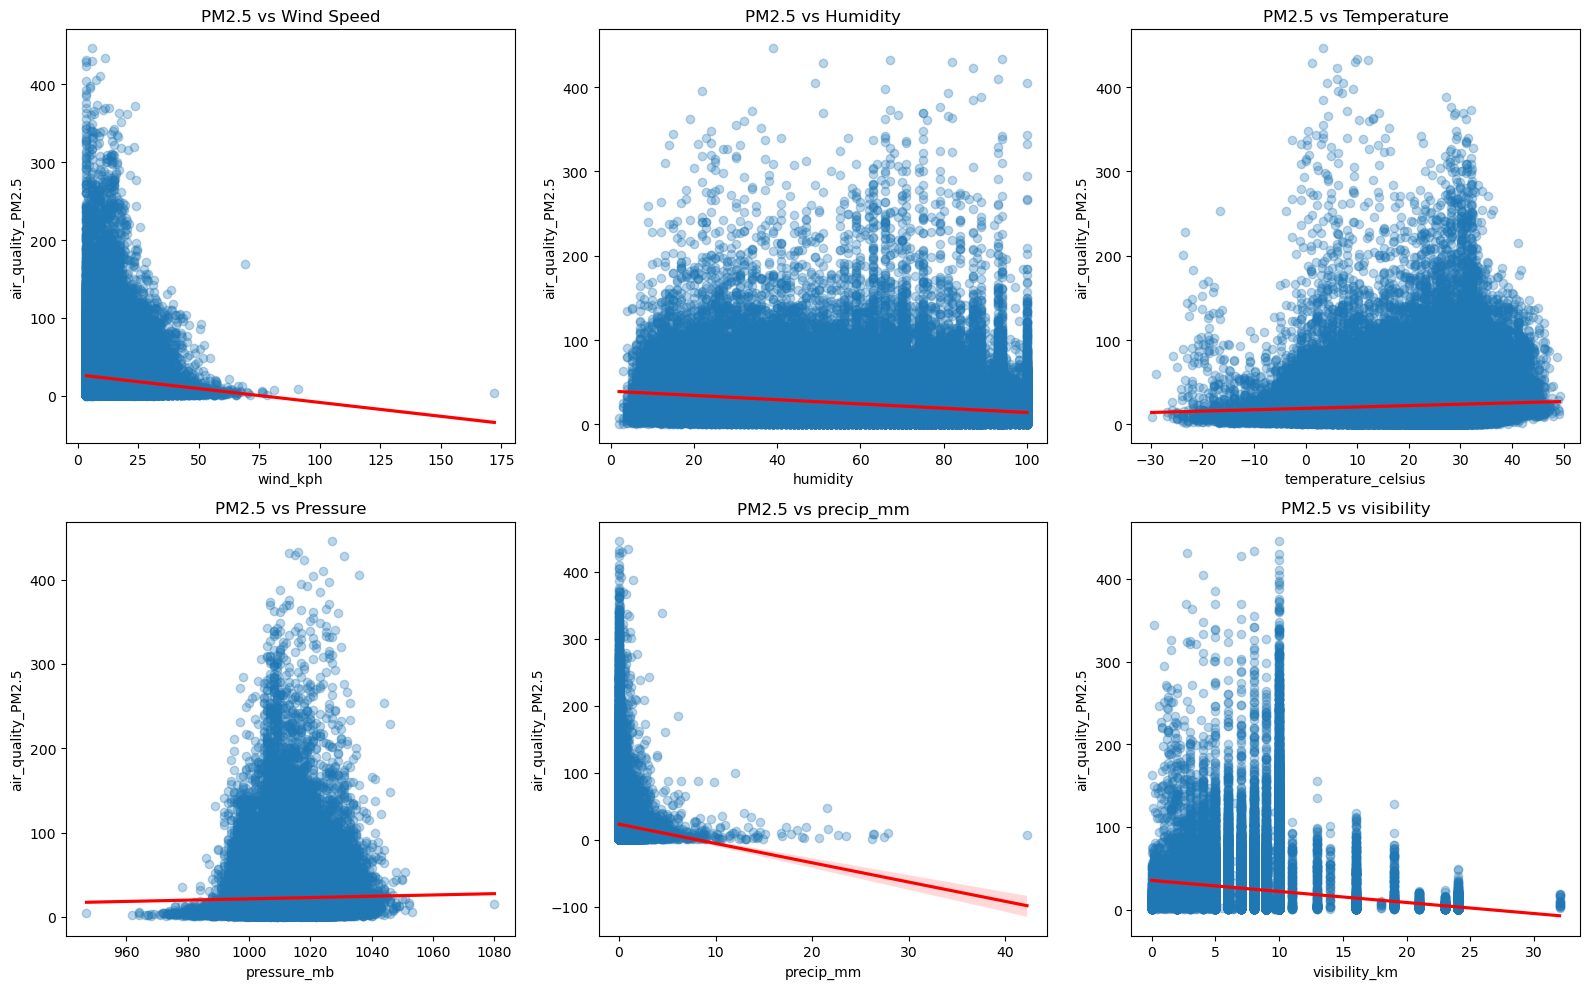

In [56]:
""" These plots illustrate how temperature, humidity, pressure_mb, precip_mm, visibility_km, and wind speed influence air pollution levels,
using scatter plots with regression lines to highlight the relationships."""
# Create a figure with 3 subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. PM2.5 vs Wind Speed
sns.regplot(ax=axes[0,0], data=df, x='wind_kph', y='air_quality_PM2.5', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0,0].set_title('PM2.5 vs Wind Speed')

# 2. PM2.5 vs Humidity
sns.regplot(ax=axes[0,1], data=df, x='humidity', y='air_quality_PM2.5', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0,1].set_title('PM2.5 vs Humidity')

# 3. PM2.5 vs Temperature
sns.regplot(ax=axes[0,2], data=df, x='temperature_celsius', y='air_quality_PM2.5', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0,2].set_title('PM2.5 vs Temperature')

sns.regplot(ax=axes[1,0], data=df, x='pressure_mb', y='air_quality_PM2.5', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[1,0].set_title('PM2.5 vs Pressure')

sns.regplot(ax=axes[1,1], data=df, x='precip_mm', y='air_quality_PM2.5', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[1,1].set_title('PM2.5 vs precip_mm')

sns.regplot(ax=axes[1,2], data=df, x='visibility_km', y='air_quality_PM2.5', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[1,2].set_title('PM2.5 vs visibility')

#'', '', ''
plt.tight_layout()
plt.show()

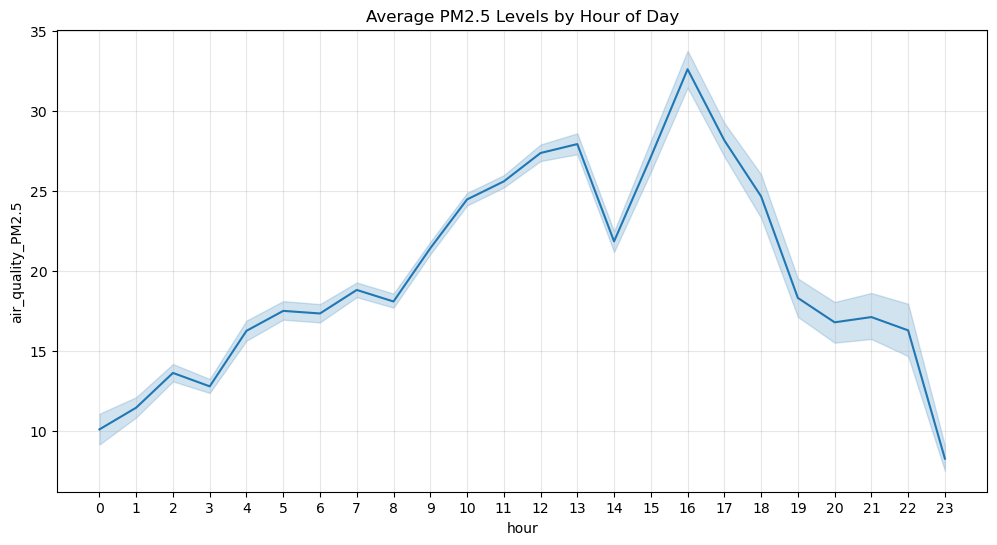

In [57]:
""" This plot helps identify the time of day when PM2.5 pollution peaks or drops, 
which can be linked to traffic patterns or weather conditions."""

# Extract the hour from the time column
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='hour', y='air_quality_PM2.5', estimator='mean')
plt.title('Average PM2.5 Levels by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
#plt.savefig(r"C:\Users\HP\Air_Pollution_Analysis\Images\pm25_levels_by_hours.png", dpi=300, bbox_inches='tight')

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_7608\38636357.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day_of_week', y='air_quality_PM2.5', order=days_order, palette='viridis')


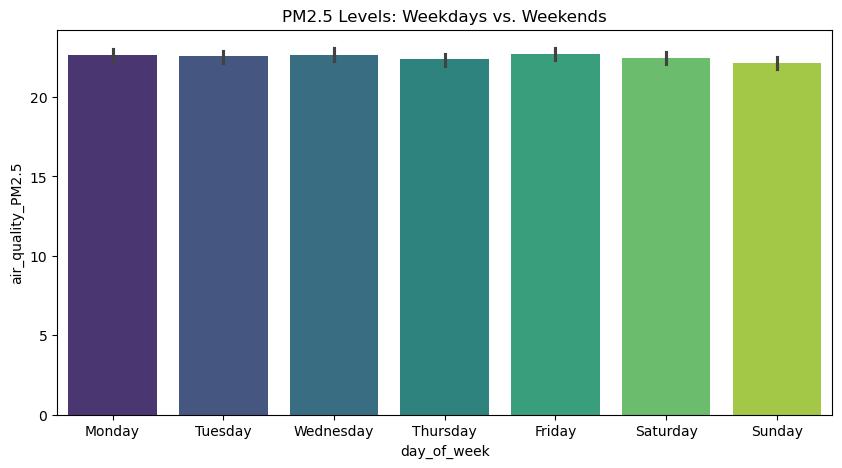

In [60]:
""" This plot allows us to compare air pollution trends across weekdays and weekends, 
helping to identify if PM2.5 levels are influenced by human activity 
patterns such as traffic or industrial operations."""

# Extract the day of the week (0=Monday, 6=Sunday) from the 'date' column for this
df['day_of_week'] = pd.to_datetime(df['date']).dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='day_of_week', y='air_quality_PM2.5', order=days_order, palette='viridis')
plt.title('PM2.5 Levels: Weekdays vs. Weekends')
plt.show()

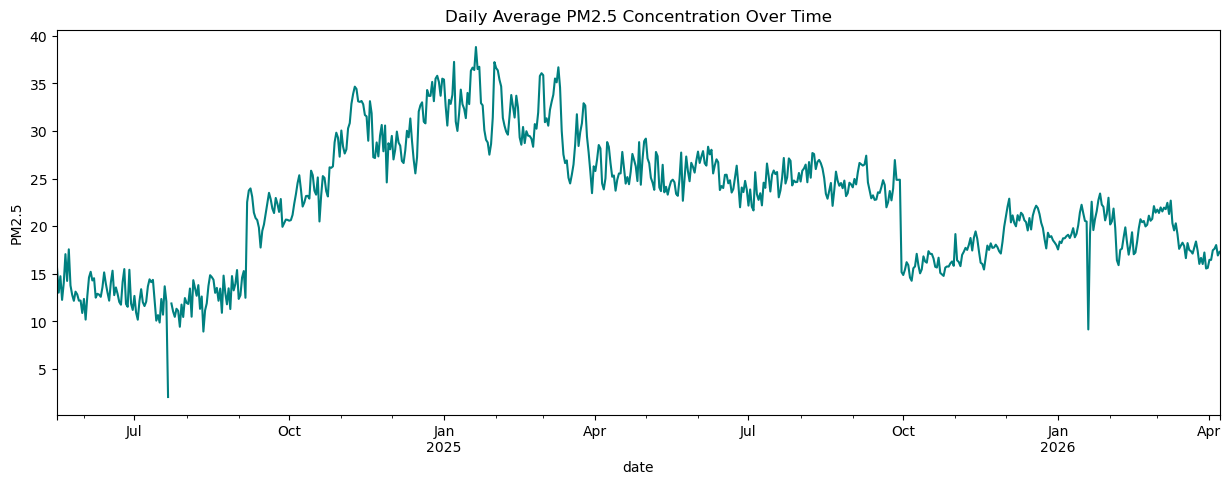

In [62]:
""" This time series plot shows trends in PM2.5 pollution over time, 
helping identify seasonal patterns, pollution spikes, or periods of cleaner air."""

# Set the date as the index
df_temp = df.set_index(pd.to_datetime(df['date']))

# Resample to Daily ('D') or Weekly ('W') averages
daily_pm25 = df_temp['air_quality_PM2.5'].resample('D').mean()

plt.figure(figsize=(15, 5))
daily_pm25.plot(color='teal')
plt.title('Daily Average PM2.5 Concentration Over Time')
plt.ylabel('PM2.5')
plt.show()

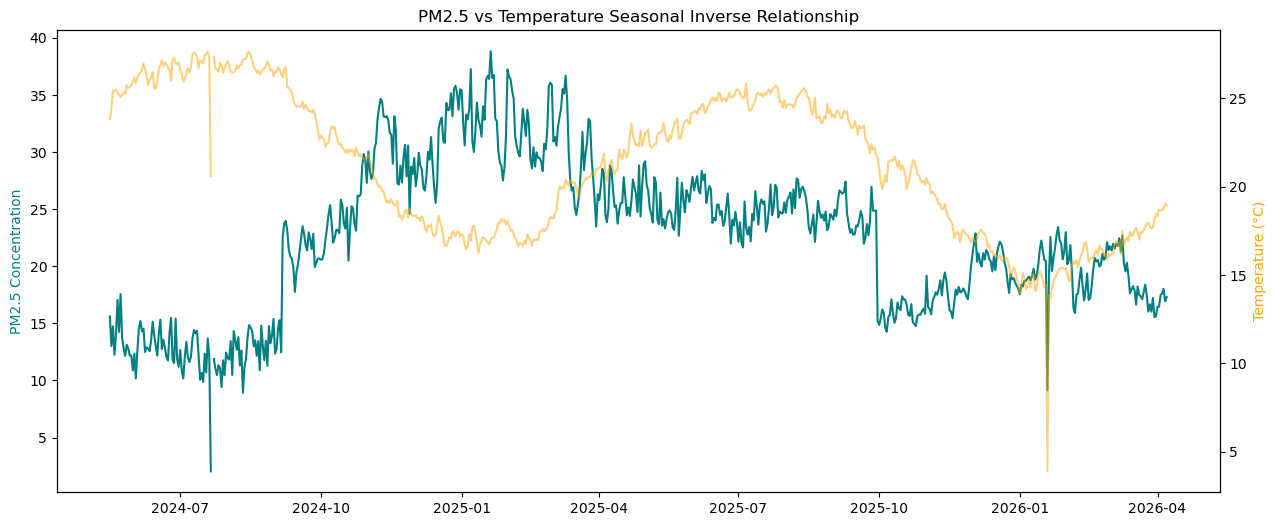

In [64]:
""" This dual-axis plot illustrates the inverse relationship between PM2.5 levels and 
temperature over time, showing that higher temperatures often coincide with lower pollution levels, 
likely due to increased dispersion and reduced emission activities."""

# Plotting two different scales on one graph
fig, ax1 = plt.subplots(figsize=(15, 6))

ax2 = ax1.twinx()
ax1.plot(daily_pm25.index, daily_pm25, color='teal', label='PM2.5')
ax2.plot(df_temp['temperature_celsius'].resample('D').mean().index, 
         df_temp['temperature_celsius'].resample('D').mean(), 
         color='orange', alpha=0.5, label='Temp')

ax1.set_ylabel('PM2.5 Concentration', color='teal')
ax2.set_ylabel('Temperature (°C)', color='orange')
plt.title('PM2.5 vs Temperature Seasonal Inverse Relationship')
#plt.savefig(r"C:\Users\HP\Air_Pollution_Analysis\Images\pm25_vs_temp_seasonal_inv_relation.png", dpi=300, bbox_inches='tight')

plt.show()

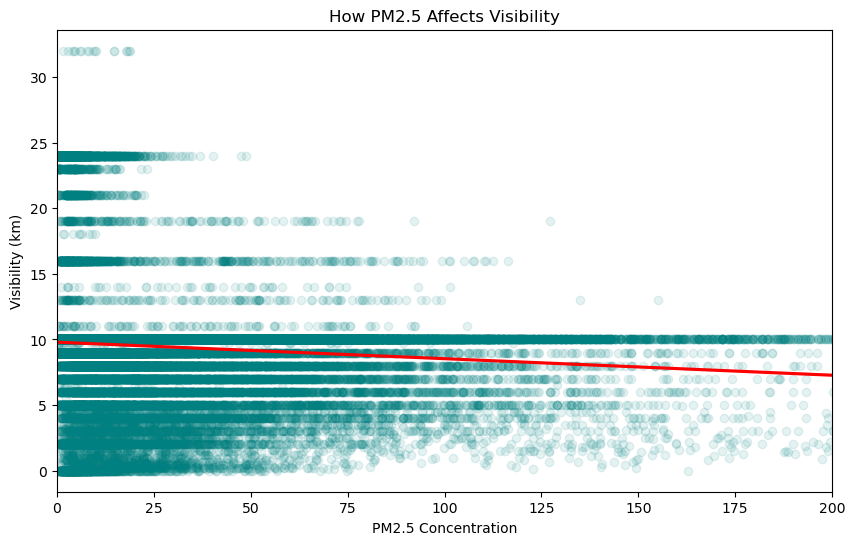

In [66]:
""" This plot shows the negative impact of PM2.5 on visibility: as particulate matter increases,
visibility decreases. The regression line helps quantify this inverse relationship."""

plt.figure(figsize=(10, 6))

# Using a scatter plot with a hexbin or transparency because of the large dataset
sns.regplot(data=df, x='air_quality_PM2.5', y='visibility_km', 
            scatter_kws={'alpha':0.1, 'color':'teal'}, line_kws={'color':'red'})
plt.title('How PM2.5 Affects Visibility')
plt.xlabel('PM2.5 Concentration')
plt.ylabel('Visibility (km)')
plt.xlim(0, 200) # Focusing on the meaningful range
plt.show()

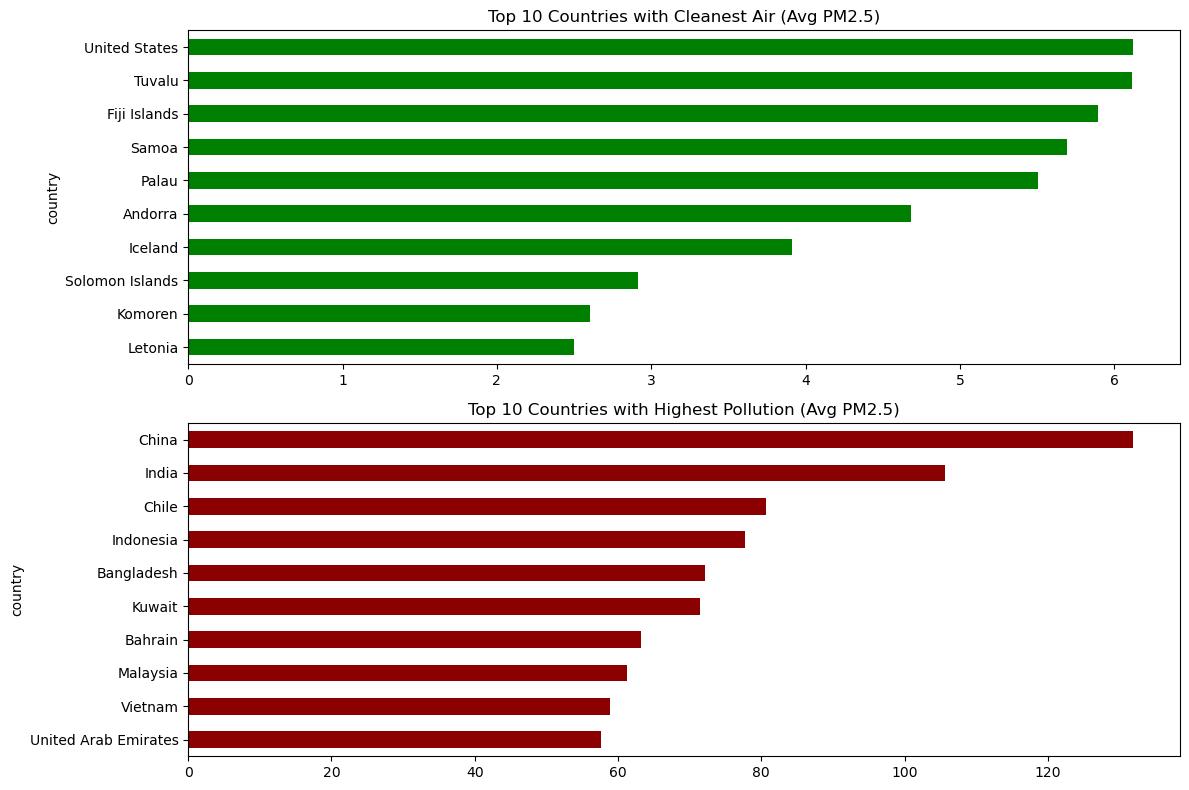

In [69]:
# Average PM2.5 by Country
country_rank = df.groupby('country')['air_quality_PM2.5'].mean().sort_values()

# Plot Top 10 Cleanest and Top 10 Most Polluted
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
country_rank.head(10).plot(kind='barh', color='green')
plt.title('Top 10 Countries with Cleanest Air (Avg PM2.5)')

plt.subplot(2, 1, 2)
country_rank.tail(10).plot(kind='barh', color='darkred')
plt.title('Top 10 Countries with Highest Pollution (Avg PM2.5)')
plt.tight_layout()
plt.show()

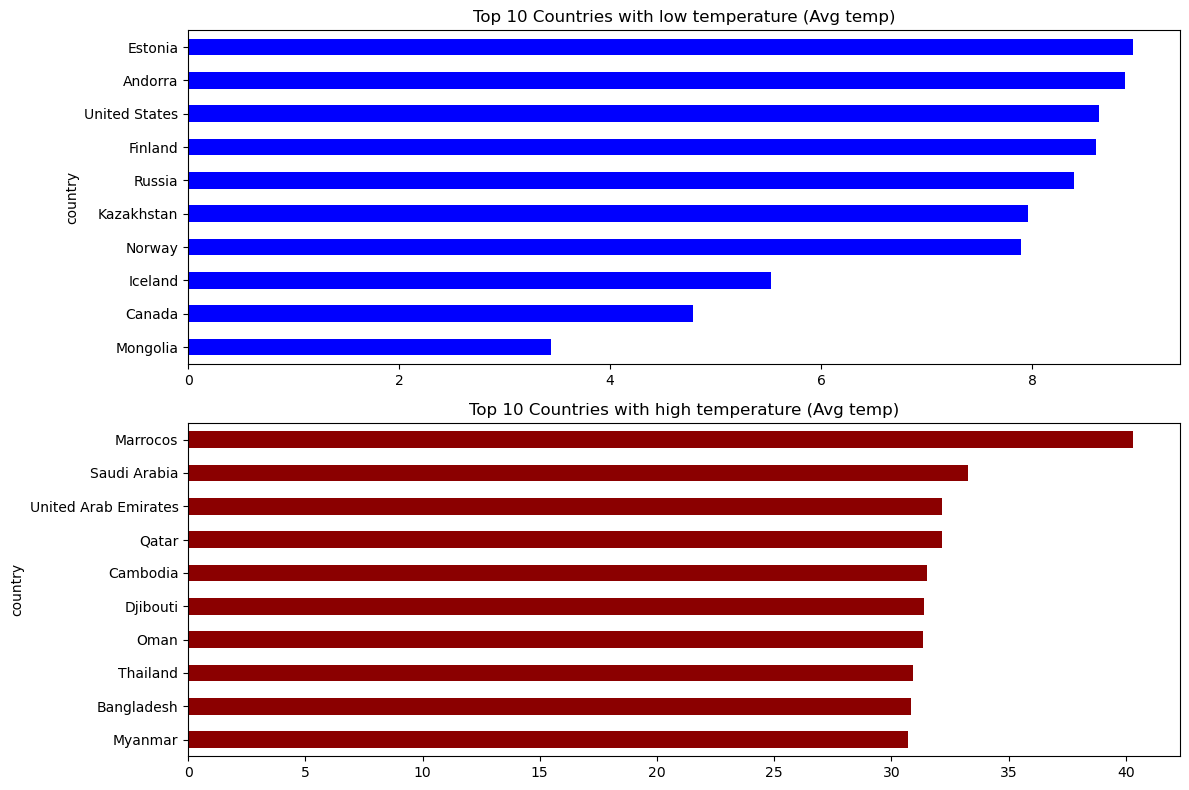

In [71]:
# Average Temperature by Country
country_rank = df.groupby('country')['temperature_celsius'].mean().sort_values()

# Plot Top 10 Hottest and Top 10 Coldest countries 
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
country_rank.head(10).plot(kind='barh', color='blue')
plt.title('Top 10 Countries with low temperature (Avg temp)')

plt.subplot(2, 1, 2)
country_rank.tail(10).plot(kind='barh', color='darkred')
plt.title('Top 10 Countries with high temperature (Avg temp)')
plt.tight_layout()
plt.show()

## Linear regression Model

In [76]:
from sklearn.model_selection import train_test_split

# Selecting features (X) and target (y)
X = df[['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb',
        'precip_mm', 'visibility_km', 'gust_kph']]

y = df['air_quality_PM2.5']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialize and train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

R2 Score: 0.07961522495319073
MAE: 16.327666036228866
RMSE: 27.62200333587193


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [80]:
# Coefficients as importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False)

print(importance)

               Feature  Coefficient
0  temperature_celsius         0.02
3          pressure_mb        -0.04
2             wind_kph        -0.11
6             gust_kph        -0.21
1             humidity        -0.26
4            precip_mm        -1.11
5        visibility_km        -1.47


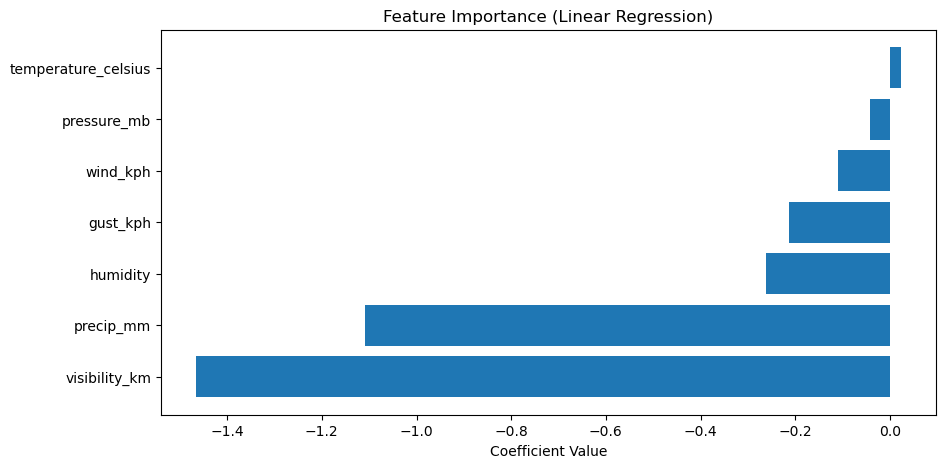

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(importance['Feature'], importance['Coefficient'])
plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
#plt.savefig(r"C:\Users\HP\Air_Pollution_Analysis\Images\feature_importance_LR.png", dpi=300, bbox_inches='tight')
plt.show()